In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
  Using cached scienceplots-2.2.1-py3-none-any.whl.metadata (14 kB)
Using cached scienceplots-2.2.1-py3-none-any.whl (30 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
J = sp.Symbol("J", real=True, positive=True)
epsilon = sp.Symbol("epsilon", real=True, positive=True)
epsilon1 = sp.Symbol("epsilon1", real=True, positive=True)
epsilon2 = sp.Symbol("epsilon2", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)
delta = sp.Symbol("delta", real=True, positive=True)
Delta1, Delta2, Delta3  = sp.symbols("Delta1 Delta2 Delta3", real=True, positive=True)
Delta31, Delta32, Delta21 = sp.symbols("Delta31 Delta32 Delta21", real=True, positive=True)
t = sp.Symbol("t", real=True, positive=True)

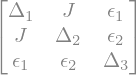

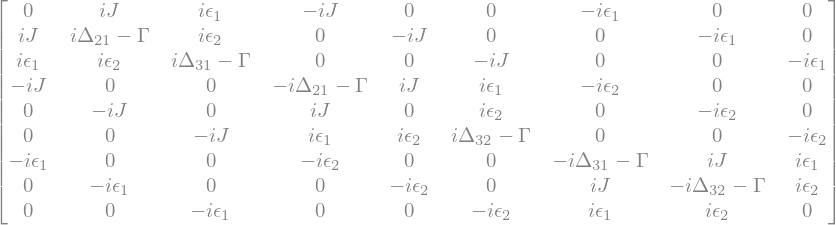

In [3]:
H = sp.Matrix([[Delta1, J, epsilon1], [J, Delta2, epsilon2], [epsilon1, epsilon2, Delta3]])
L, rho = lindbladian(3, output=False, degenerate=False, H=H)

# dephasing
L = L.subs({sp.Symbol(f"Gamma_{i}→{i}", real=True, nonnegative=True): gamma for i in range(64)})

# no population transitions
L = L.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(64) for j in range(64)})

# writing in terms of site energy differences
L = L.subs({Delta3-Delta1:Delta31,Delta3-Delta2:Delta32, Delta2-Delta1:Delta21})

display(H)
display(L)

In [4]:
mathematica_code(L).replace("Gamma","Γ").replace("epsilon1", "ϵ").replace("epsilon2", "α").replace("Delta31", "θ").replace("Delta32", "τ").replace("Delta21", "β")

'{{0, I*J, I*ϵ, -I*J, 0, 0, -I*ϵ, 0, 0}, {I*J, I*β - Γ, I*α, 0, -I*J, 0, 0, -I*ϵ, 0}, {I*ϵ, I*α, I*θ - Γ, 0, 0, -I*J, 0, 0, -I*ϵ}, {-I*J, 0, 0, -I*β - Γ, I*J, I*ϵ, -I*α, 0, 0}, {0, -I*J, 0, I*J, 0, I*α, 0, -I*α, 0}, {0, 0, -I*J, I*ϵ, I*α, I*τ - Γ, 0, 0, -I*α}, {-I*ϵ, 0, 0, -I*α, 0, 0, -I*θ - Γ, I*J, I*ϵ}, {0, -I*ϵ, 0, 0, -I*α, 0, I*J, -I*τ - Γ, I*α}, {0, 0, -I*ϵ, 0, 0, -I*α, I*ϵ, I*α, 0}}'

In [13]:
evals_string = '''
(-3*\[CapitalGamma]*(J^2*(\[Alpha]^2 + \[Epsilon]^2) + \[CapitalGamma]^2*(\[Alpha]^2 + \[Epsilon]^2) + 2*J*\[Alpha]*\[Epsilon]*(\[Theta] + \[Tau])))/(J^2 + \[CapitalGamma]^2)^2
'''

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_401/1102183718.py:2: SyntaxWarning: invalid escape sequence '\['
  (-3*\[CapitalGamma]*(J^2*(\[Alpha]^2 + \[Epsilon]^2) + \[CapitalGamma]^2*(\[Alpha]^2 + \[Epsilon]^2) + 2*J*\[Alpha]*\[Epsilon]*(\[Theta] + \[Tau])))/(J^2 + \[CapitalGamma]^2)^2


# eigenvalues approximated to $O(\epsilon_i^4)$ with $\epsilon_i\sim\Delta_i$, no restriction on $\Gamma$

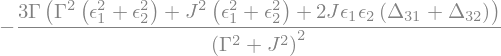

++++++++++++++++++++++++++++++


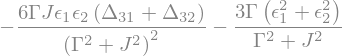

In [16]:
evals_approx = [parse_mathematica(evals_string.replace(r"\[CapitalGamma]", "Gamma").replace(r"\[Epsilon]", "epsilon1").replace(r"\[Alpha]", "epsilon2").replace(r"\[Theta]", "Delta31").replace(r"\[Tau]", "Delta32").replace(r"\[Beta]", "Delta21"))]

evals_approx = [i.subs({sp.Symbol("Gamma"): gamma, sp.Symbol("epsilon1"): epsilon1, sp.Symbol("epsilon2"): epsilon2, sp.Symbol("J"): J, sp.Symbol("Delta31"): Delta31, sp.Symbol("Delta32"): Delta32, sp.Symbol("Delta21"): Delta21}) for i in evals_approx]


for i in evals_approx:
    display(i)
    print("++++++++++++++++++++++++++++++")

             
             
expr = -3*gamma*(epsilon1**2+epsilon2**2)/(gamma**2+J**2) -6*gamma*J*epsilon1*epsilon2*(Delta31+Delta32)*(gamma**2+J**2)**(-2)

display(expr)

evals_approx[0]=expr


# big $\Gamma$ limit

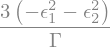

In [54]:
# big gamma limit - second order in eta=1/gamma
evals_big_gamma = []
for i in evals_approx:
    i = i.subs(gamma, 1/sp.Symbol('eta')).series(sp.Symbol('eta'), 0, 2).subs({sp.Symbol('eta'): 1/gamma, epsilon1**2*epsilon2**2: 0}).removeO()
    evals_big_gamma.append(i)
    display(i.simplify())
    

# small $\Gamma$ limit

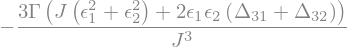

In [71]:
# small gamma limit - second order
evals_small_gamma = []
for i in evals_approx:
    i = i.series(gamma, 0, 3).subs(epsilon1**2*epsilon2**2, 0).removeO().simplify()
    evals_small_gamma.append(i)
    display(i)

# case 1: set $\epsilon_1=\epsilon_2=\epsilon$

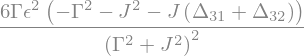

In [72]:
# general
evals_approx[0].subs({epsilon1:epsilon, epsilon2: epsilon}).simplify()

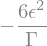

In [73]:
# big gamma
evals_big_gamma[0].subs({epsilon1:epsilon, epsilon2:epsilon}).simplify()

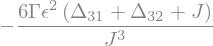

In [74]:
# small gamma
evals_small_gamma[0].subs({epsilon1:epsilon, epsilon2: epsilon}).simplify()

# case 2: set $\epsilon_1=0$ and $\epsilon_2=\epsilon$

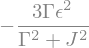

In [59]:
# general
evals_approx[0].subs({epsilon1:0, epsilon2: epsilon}).simplify()

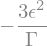

In [60]:
# big gamma
evals_big_gamma[0].subs({epsilon1:0, epsilon2: epsilon}).simplify()

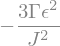

In [61]:
# small gamma
evals_small_gamma[0].subs({epsilon1:0, epsilon2: epsilon}).simplify().factor()

# case 3: set $\epsilon_1 = \epsilon + \delta$ and $\epsilon_2 = \epsilon - \delta$

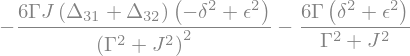

In [85]:
# general
a = evals_approx[0].subs({epsilon1:epsilon+delta, epsilon2:epsilon-delta}).simplify(deep=True)

b = -6*gamma*(delta**2+epsilon**2)/(gamma**2+J**2)-6*gamma*J*(epsilon**2-delta**2)*(Delta31+Delta32)*(gamma**2+J**2)**(-2)

b

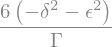

In [63]:
# big gamma
evals_big_gamma[0].subs({epsilon1:epsilon+delta, epsilon2:epsilon-delta}).simplify(deep=True)

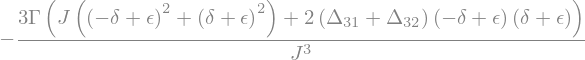

In [88]:
# small gamma
evals_small_gamma[0].subs({epsilon1:epsilon+delta, epsilon2:epsilon-delta})